# AtmoSync
## 03 - Exploratory Data Analysis

### Objective

Explore the distribution and relationships of environmental variables.

### Questions

1. How does temperature change throughout the day?
2. How does humidity change throughout the day?
3. Which LULC type has the highest temperature?
4. Which LULC type has the highest NDVI?
5. Which locations have unusual temperatures?
6. What relationships exist between environmental variables?

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "dataset"
    / "processed"
    / "microclimate_cleaned.csv"
)

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["cdTimestamp"]
)

df.head()

,cdTimestamp,Location_ID,Latitude,Longitude,LULC_Type,Temperature,Humidity,Wind_Speed,Solar_Radiation,Precipitation,Air_Pressure,NDVI,Hour,Minute,Time_Period,Temperature_Anomaly,Dew_Point_C,NDVI_Category,Solar_Radiation_Band
0,2022-01-01 00:00:00,Station_1,42.920785,-70.442076,Agricultural,-1.45,30.99,1.03,747.73,9,980.36,0.87,0.000000,0,Night,-14.164132,-16.372129,Very High,Very High
1,2022-01-01 00:05:00,Station_1,45.878954,-88.553180,Forest,24.93,58.33,9.05,297.29,0,1020.30,0.56,0.083333,5,Night,12.215868,16.174638,High,Moderate
2,2022-01-01 00:10:00,Station_1,32.147619,-91.387175,Agricultural,20.60,74.46,8.63,549.58,2,1024.56,0.52,0.166667,10,Night,7.885868,15.894248,High,High
3,2022-01-01 00:15:00,Station_1,26.725934,-114.654620,Barren,3.09,65.30,7.90,755.51,10,1043.17,0.46,0.250000,15,Night,-9.624132,-2.782506,Moderate,Very High
4,2022-01-01 00:20:00,Station_1,40.877759,-92.345482,Barren,17.44,44.88,11.49,979.98,1,998.33,0.47,0.333333,20,Night,4.725868,5.337919,Moderate,Very High


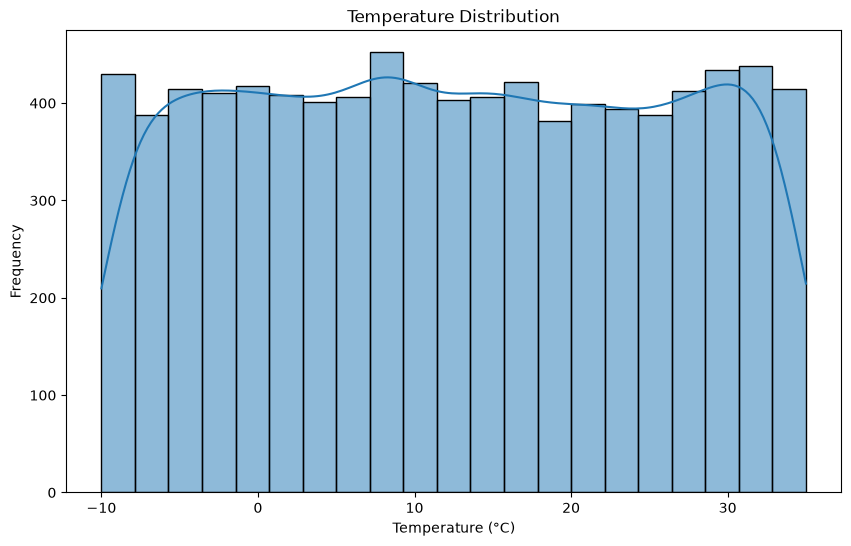

In [4]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Temperature"],
    kde=True
)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

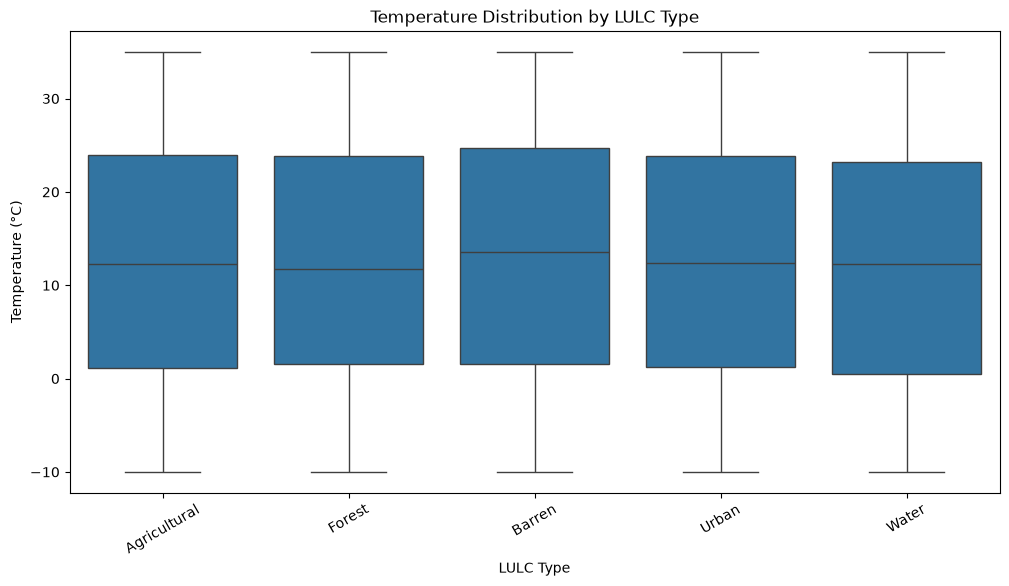

In [5]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="LULC_Type",
    y="Temperature"
)

plt.xticks(rotation=30)

plt.title(
    "Temperature Distribution by LULC Type"
)

plt.xlabel("LULC Type")
plt.ylabel("Temperature (°C)")

plt.show()

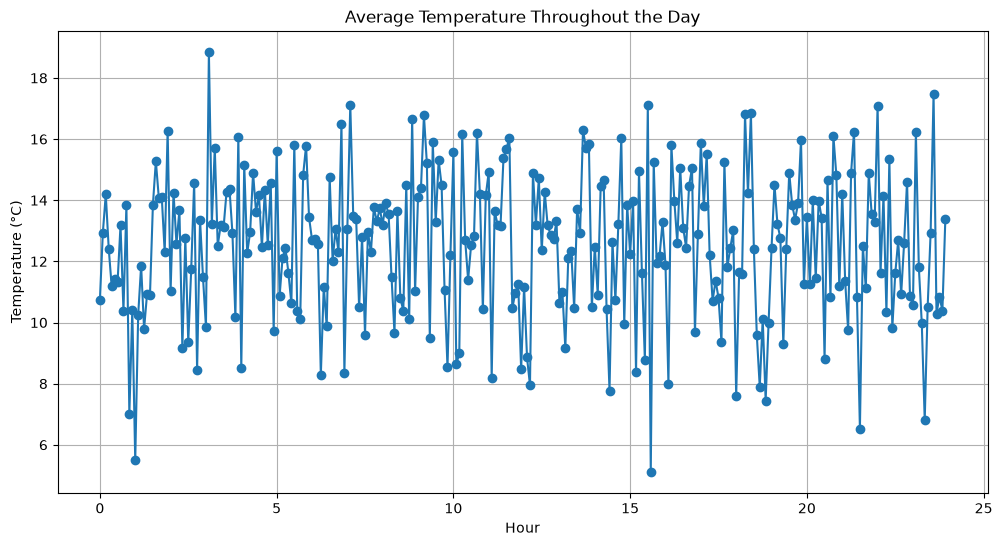

In [6]:
hourly_temperature = (
    df.groupby("Hour")["Temperature"]
    .mean()
)

plt.figure(figsize=(12, 6))

plt.plot(
    hourly_temperature.index,
    hourly_temperature.values,
    marker="o"
)

plt.title(
    "Average Temperature Throughout the Day"
)

plt.xlabel("Hour")
plt.ylabel("Temperature (°C)")

plt.grid(True)

plt.show()

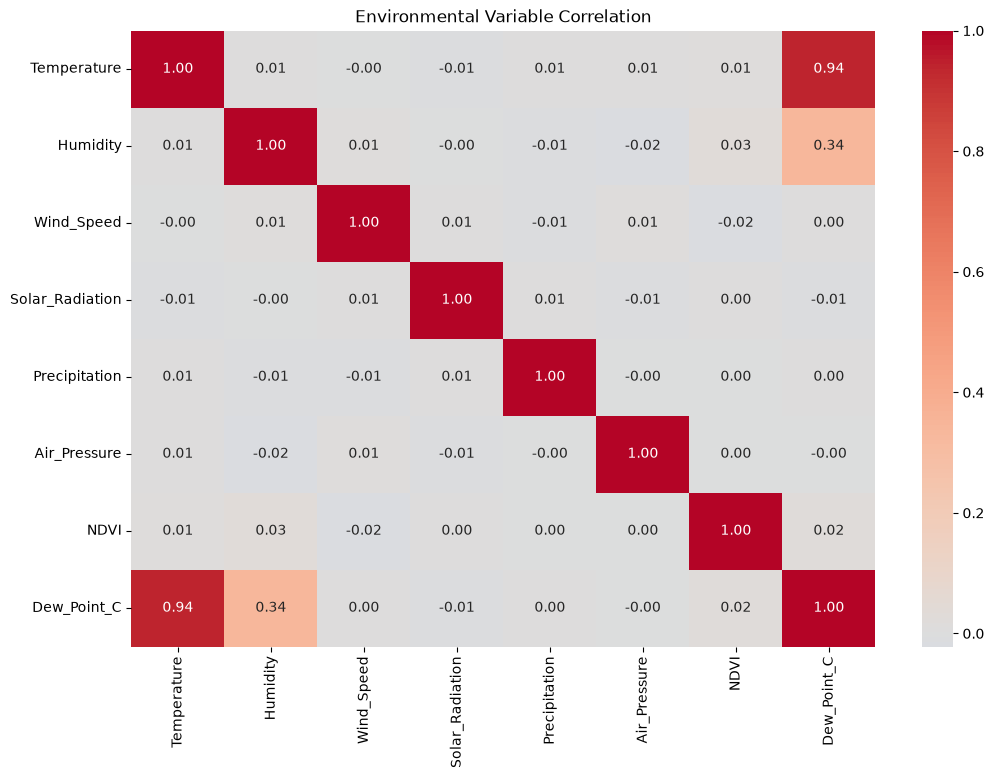

In [7]:
numeric_columns = [
    "Temperature",
    "Humidity",
    "Wind_Speed",
    "Solar_Radiation",
    "Precipitation",
    "Air_Pressure",
    "NDVI",
    "Dew_Point_C"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Environmental Variable Correlation"
)

plt.show()